# **Analisis Association Rule untuk Menemukan Pola Perilaku dan Produktivitas Mahasiswa Menggunakan Algoritma Apriori Algorithm dan FP-Growth pada Dataset Student Productivity and Behavior**

# **PROJECT AKHIR PENAMBANGAN DATA KELOMPOK 10**

Nama Anggota Kelompok:
1. Yanaka Sofia Pardede (24031554065)
2. Fajria Rasmi Ridha Rumkel (24031554191)
3. Annisa Ramadhani (24031554206)

Kelas : 2024B

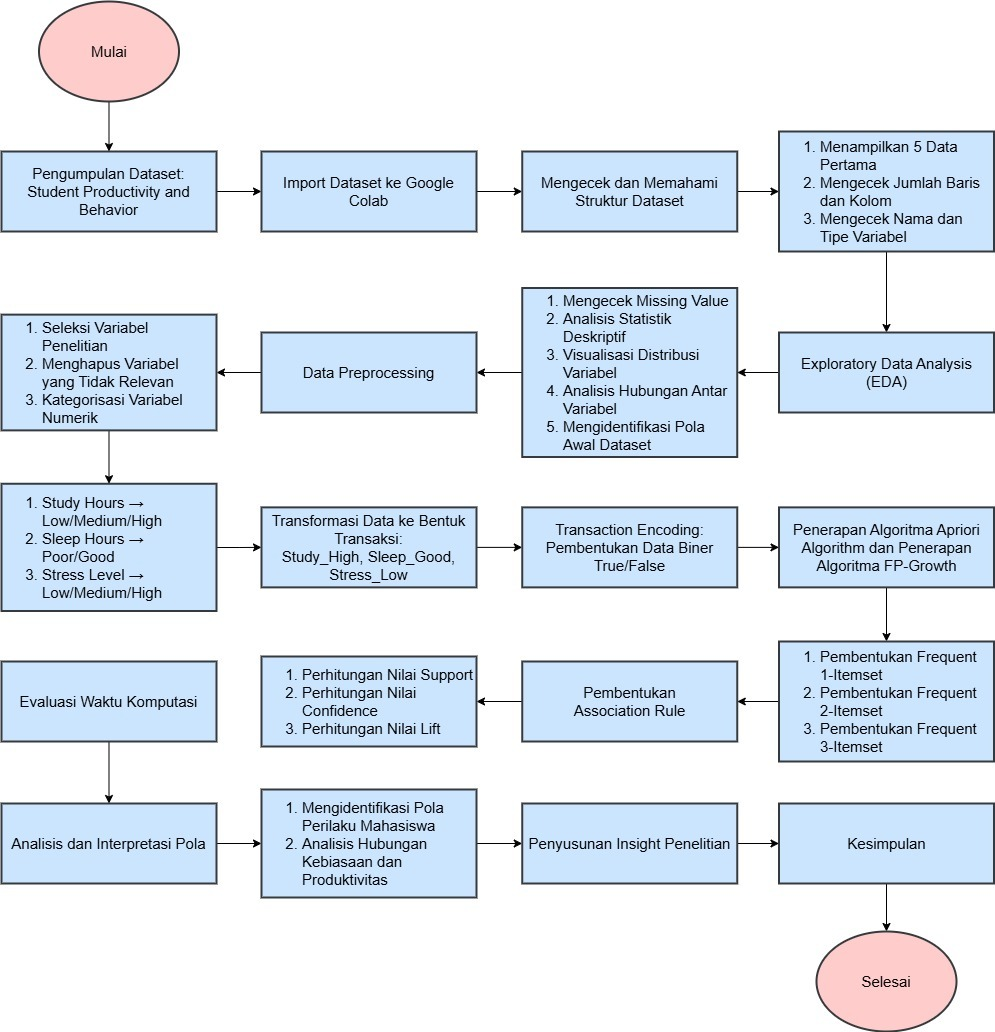

## **IMPORT LIBRARY**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import time

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.preprocessing import TransactionEncoder

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## **LOAD DATASET**

In [ ]:
warnings.filterwarnings('ignore')
from google.colab import drive
drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Mounted at /content/drive


In [ ]:
path = "/content/drive/Shareddrives/PROJECT DATMIN KEL 10/student_productivity_distraction_dataset_20000.csv"
df = pd.read_csv(path)

print("Dataset berhasil dimuat")

Dataset berhasil dimuat


## **DATA UNDERSTANDING**

In [ ]:
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


### **CEK JUMLAH DATA**

In [ ]:
print("Jumlah baris dan kolom:")
print(df.shape)

Jumlah baris dan kolom:
(20000, 18)


### **PEMERIKSAAN STRUKTUR DATASET**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

## **EXPLORATORY DATA ANALYSIS (EDA)**

### **CEK MISSING VALUE**

In [ ]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
sleep_hours,0
phone_usage_hours,0
social_media_hours,0
youtube_hours,0
gaming_hours,0
breaks_per_day,0


### **STATISTIK DESKRIPTIF**

In [ ]:
df.describe()

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,5773.647028,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,1.000000,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,5000.750000,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,20000.000000,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


### **CEK DATA DUPLIKAT**

In [ ]:
print("Jumlah data duplikat:")
print(df.duplicated().sum())

Jumlah data duplikat:
0


## **DATA PREPROCESSING**

### **SELEKSI VARIABEL PENELITIAN**

In [ ]:
selected_columns = [
    'study_hours_per_day',
    'sleep_hours',
    'social_media_hours',
    'stress_level',
    'phone_usage_hours',
    'exercise_minutes',
    'attendance_percentage',
    'productivity_score'
]

df = df[selected_columns]
df.head()

,study_hours_per_day,sleep_hours,social_media_hours,stress_level,phone_usage_hours,exercise_minutes,attendance_percentage,productivity_score
0,4.35,3.63,2.73,10,3.38,111,57.21,33.78
1,6.14,6.58,1.51,10,5.48,28,91.27,48.99
2,4.98,3.26,3.63,2,4.83,102,63.14,36.60
3,3.19,4.58,3.95,6,10.06,28,40.51,19.87
4,7.67,6.21,1.59,6,3.02,105,45.53,52.90


### **CEK OUTLIER**

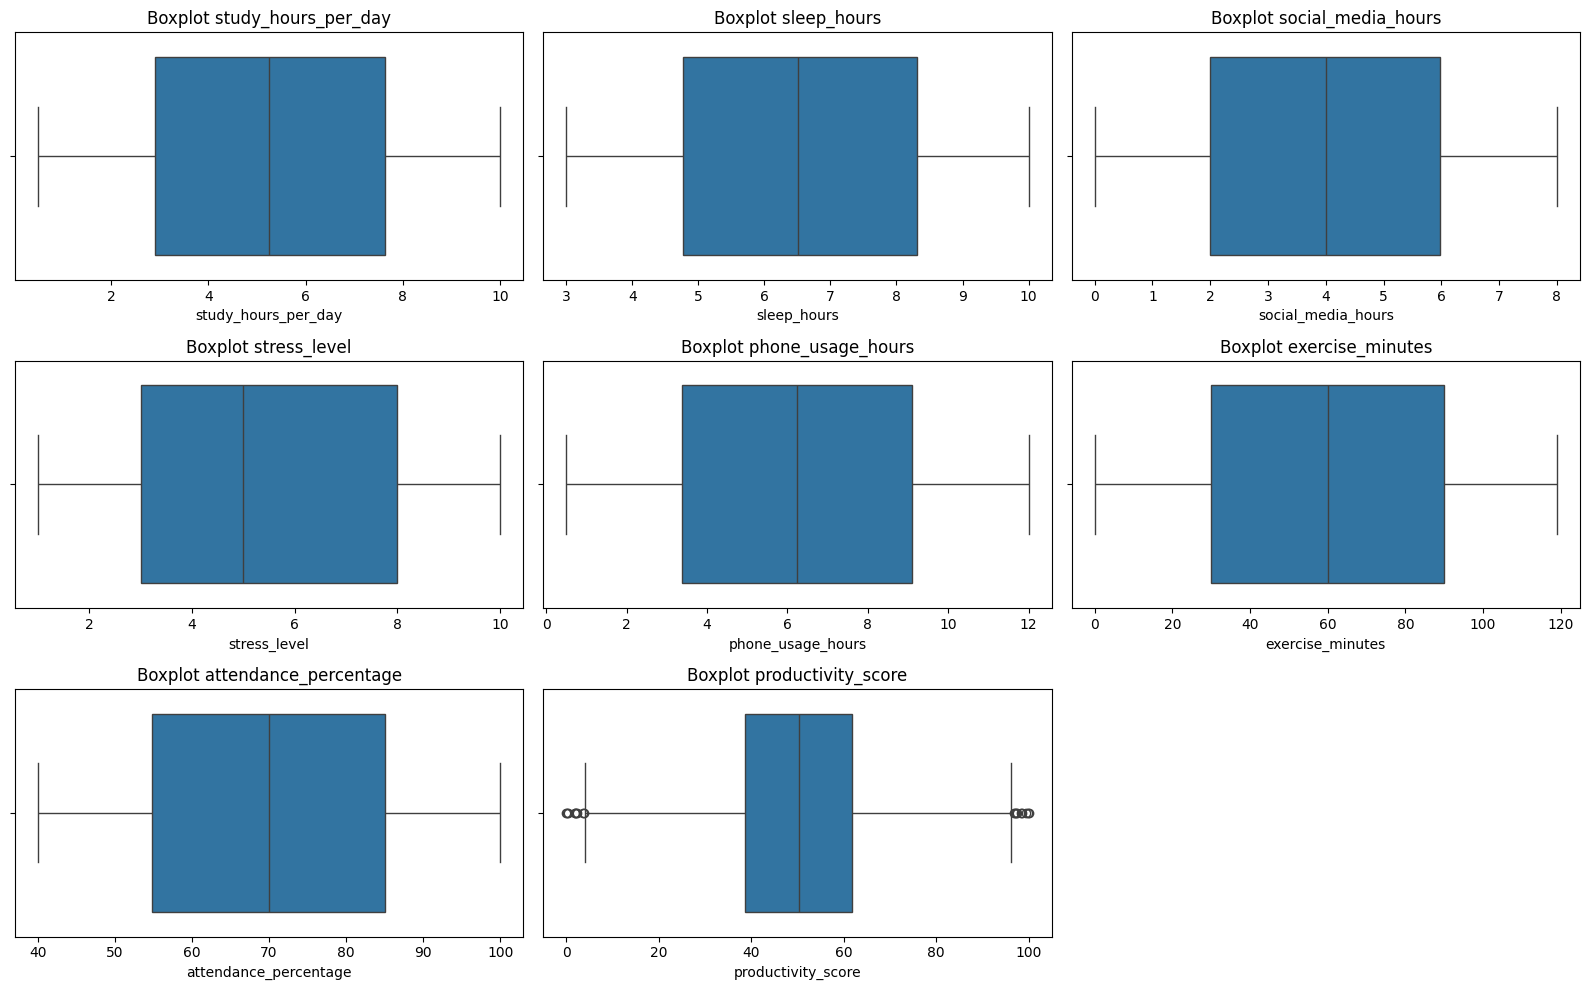

In [ ]:
numeric_columns = df.select_dtypes(
    include=['int64', 'float64']
).columns

plt.figure(figsize=(16,10))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(
        x=df[col]
    )

    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

## **VISUALISASI**

### **VISUALISASI DISTRIBUSI VARIABEL**

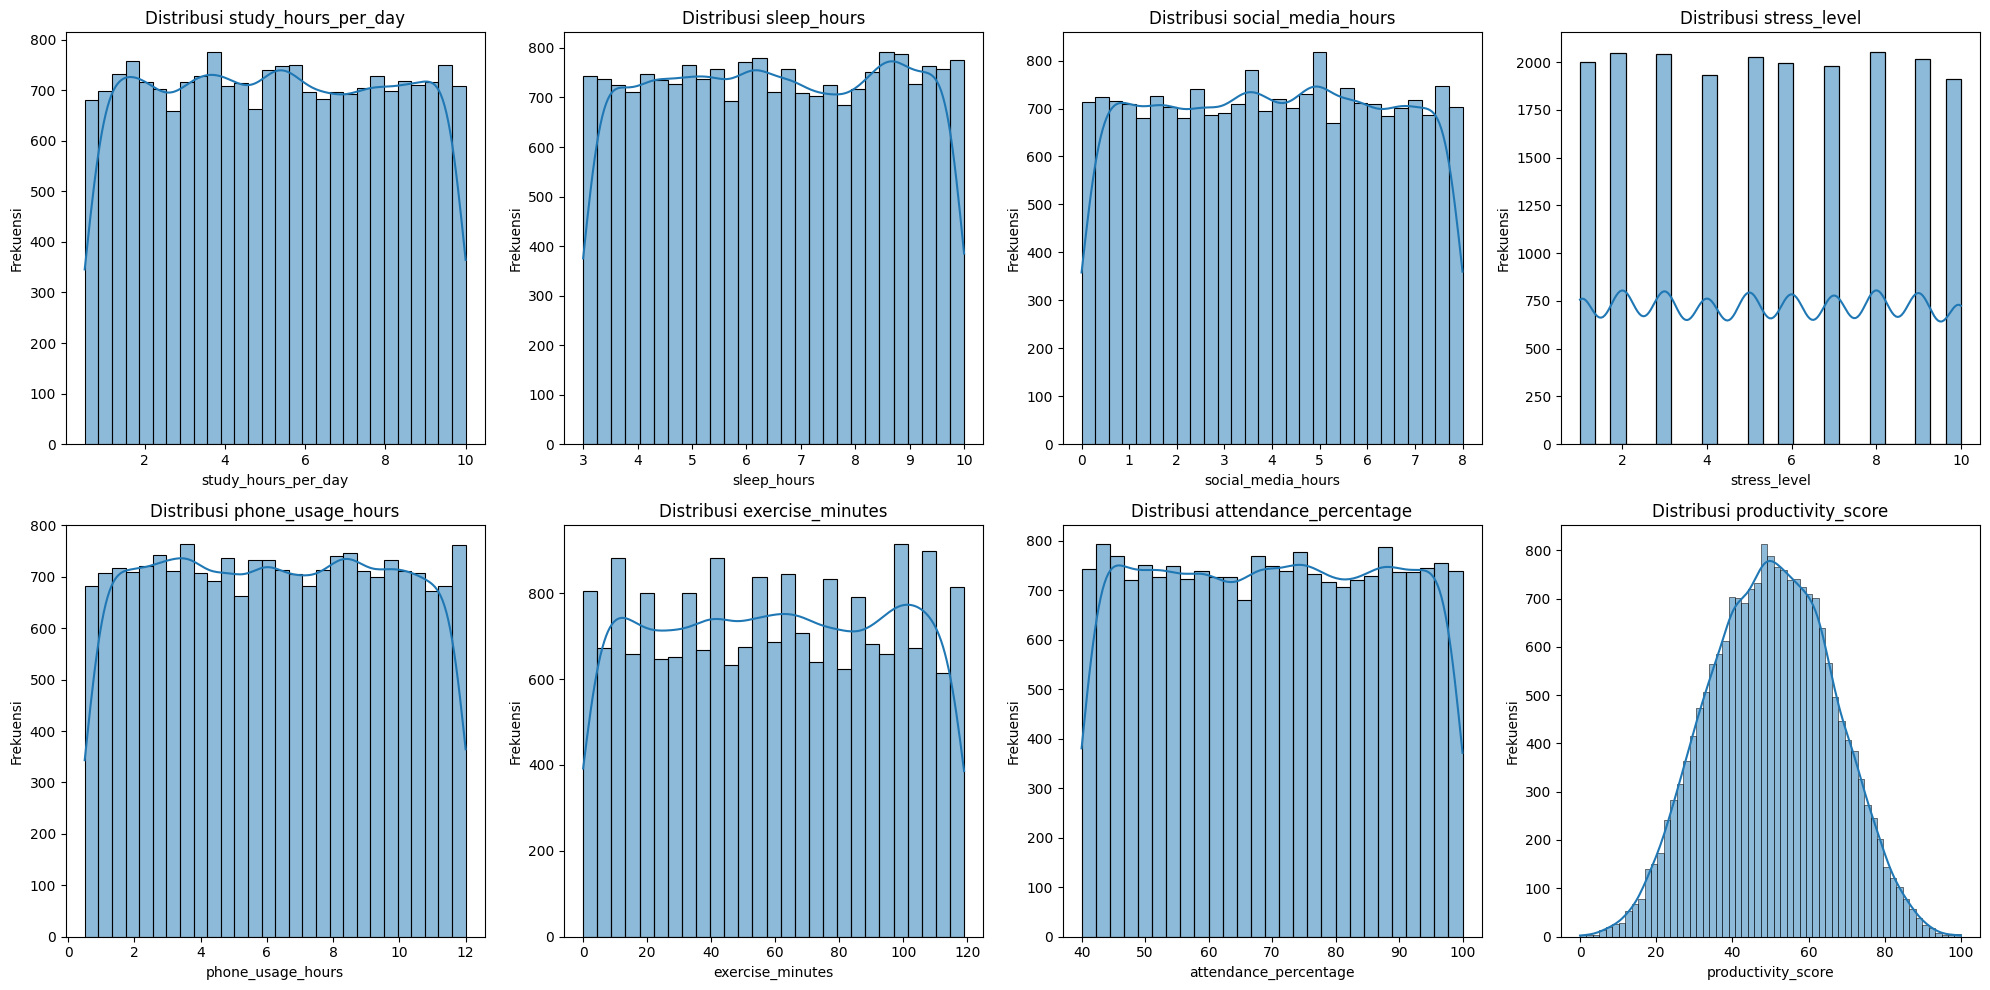

In [ ]:
numeric_columns = [
    'study_hours_per_day',
    'sleep_hours',
    'social_media_hours',
    'stress_level',
    'phone_usage_hours',
    'exercise_minutes',
    'attendance_percentage',
    'productivity_score'
]

plt.figure(figsize=(20,10))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 4, i)
    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f'Distribusi {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

### **VISUALISASI DISTRIBUSI DATA**

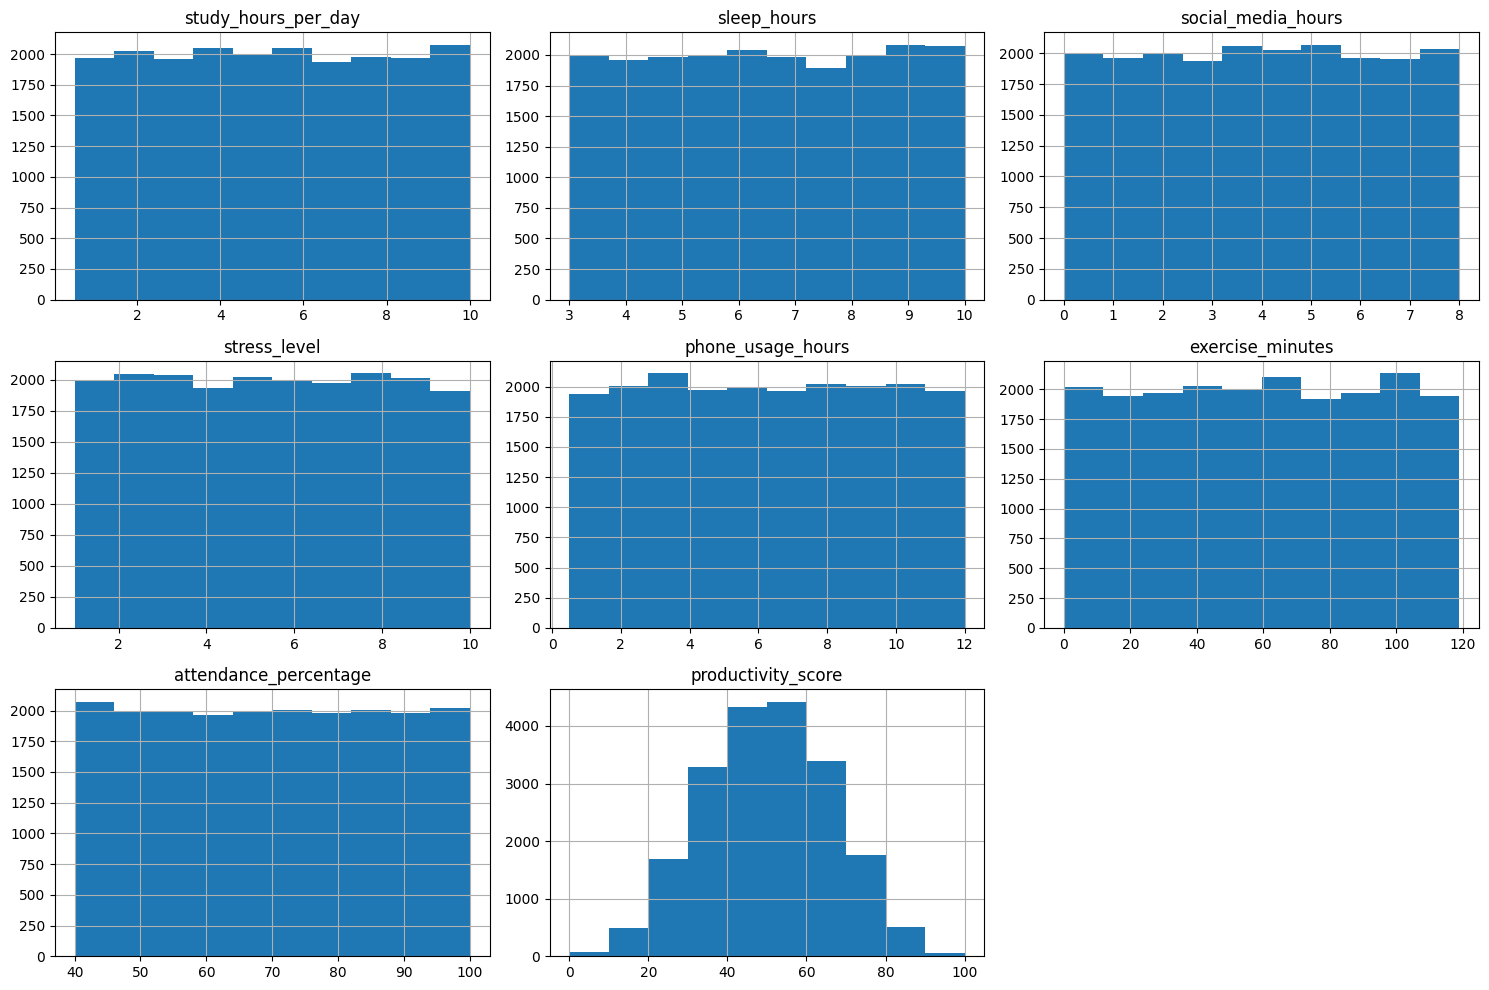

In [ ]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

### **HEATMAP KORELASI**

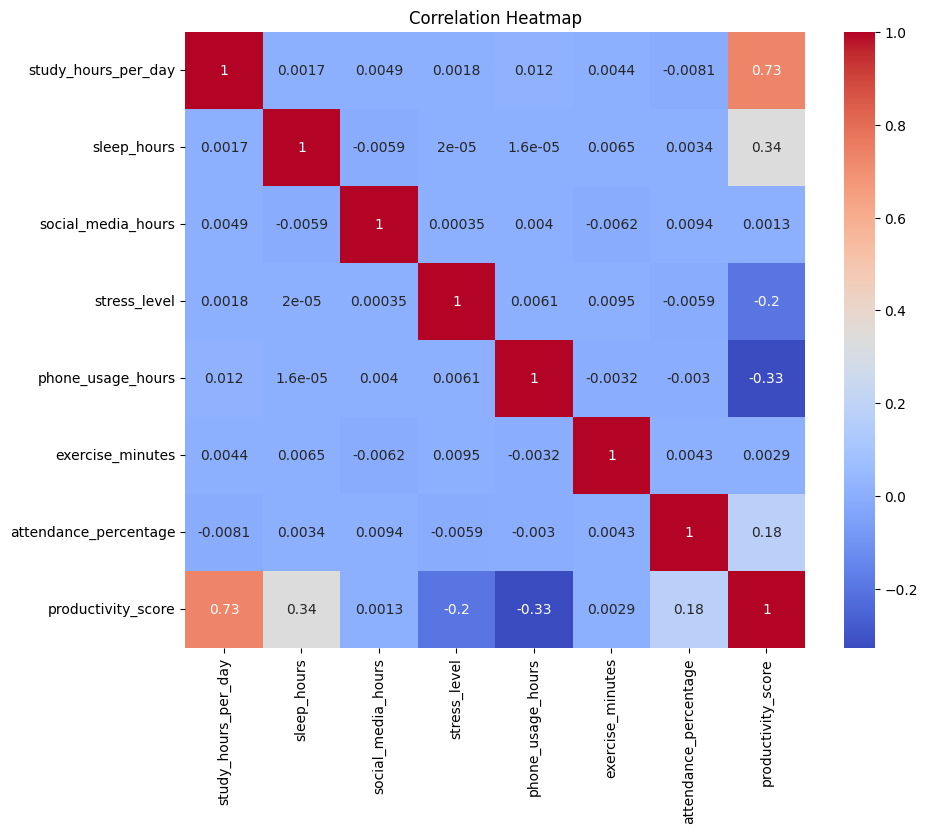

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## **DISKRETISASI DATA**

In [ ]:
df['study_category'] = pd.cut(
    df['study_hours_per_day'],
    bins=[0, 2, 5, 24],
    labels=['study_low', 'study_medium', 'study_high']
)

df['sleep_category'] = pd.cut(
    df['sleep_hours'],
    bins=[0, 5, 7, 24],
    labels=['sleep_low', 'sleep_good', 'sleep_high']
)

df['social_category'] = pd.cut(
    df['social_media_hours'],
    bins=[0, 2, 5, 24],
    labels=['social_low', 'social_medium', 'social_high']
)

df['stress_category'] = pd.cut(
    df['stress_level'],
    bins=[0, 3, 7, 10],
    labels=['stress_low', 'stress_medium', 'stress_high']
)

df['phone_category'] = pd.cut(
    df['phone_usage_hours'],
    bins=[0, 3, 6, 24],
    labels=['phone_low', 'phone_medium', 'phone_high']
)

df['exercise_category'] = pd.cut(
    df['exercise_minutes'],
    bins=[0, 20, 60, 300],
    labels=['exercise_low', 'exercise_medium', 'exercise_high']
)

df['attendance_category'] = pd.cut(
    df['attendance_percentage'],
    bins=[0, 70, 85, 100],
    labels=['attendance_low', 'attendance_medium', 'attendance_high']
)

df['productivity_category'] = pd.cut(
    df['productivity_score'],
    bins=[0, 40, 70, 100],
    labels=['productivity_low', 'productivity_medium', 'productivity_high']
)

df.head()

,study_hours_per_day,sleep_hours,social_media_hours,stress_level,phone_usage_hours,exercise_minutes,attendance_percentage,productivity_score,study_category,sleep_category,social_category,stress_category,phone_category,exercise_category,attendance_category,productivity_category
0,4.35,3.63,2.73,10,3.38,111,57.21,33.78,study_medium,sleep_low,social_medium,stress_high,phone_medium,exercise_high,attendance_low,productivity_low
1,6.14,6.58,1.51,10,5.48,28,91.27,48.99,study_high,sleep_good,social_low,stress_high,phone_medium,exercise_medium,attendance_high,productivity_medium
2,4.98,3.26,3.63,2,4.83,102,63.14,36.60,study_medium,sleep_low,social_medium,stress_low,phone_medium,exercise_high,attendance_low,productivity_low
3,3.19,4.58,3.95,6,10.06,28,40.51,19.87,study_medium,sleep_low,social_medium,stress_medium,phone_high,exercise_medium,attendance_low,productivity_low
4,7.67,6.21,1.59,6,3.02,105,45.53,52.90,study_high,sleep_good,social_low,stress_medium,phone_medium,exercise_high,attendance_low,productivity_medium


## **TRANSFORMASI**

In [ ]:
transactions = []
for i in range(len(df)):
    transaction = [
        str(df['study_category'].iloc[i]),
        str(df['sleep_category'].iloc[i]),
        str(df['social_category'].iloc[i]),
        str(df['stress_category'].iloc[i]),
        str(df['phone_category'].iloc[i]),
        str(df['exercise_category'].iloc[i]),
        str(df['attendance_category'].iloc[i]),
        str(df['productivity_category'].iloc[i])
    ]
    transactions.append(transaction)

print("Contoh Bentuk Transaksi:")
transactions[:8]

Contoh Bentuk Transaksi:


[['study_medium',
  'sleep_low',
  'social_medium',
  'stress_high',
  'phone_medium',
  'exercise_high',
  'attendance_low',
  'productivity_low'],
 ['study_high',
  'sleep_good',
  'social_low',
  'stress_high',
  'phone_medium',
  'exercise_medium',
  'attendance_high',
  'productivity_medium'],
 ['study_medium',
  'sleep_low',
  'social_medium',
  'stress_low',
  'phone_medium',
  'exercise_high',
  'attendance_low',
  'productivity_low'],
 ['study_medium',
  'sleep_low',
  'social_medium',
  'stress_medium',
  'phone_high',
  'exercise_medium',
  'attendance_low',
  'productivity_low'],
 ['study_high',
  'sleep_good',
  'social_low',
  'stress_medium',
  'phone_medium',
  'exercise_high',
  'attendance_low',
  'productivity_medium'],
 ['study_high',
  'sleep_low',
  'social_medium',
  'stress_high',
  'phone_medium',
  'exercise_low',
  'attendance_low',
  'productivity_medium'],
 ['study_high',
  'sleep_good',
  'social_high',
  'stress_high',
  'phone_high',
  'exercise_medium',

## **TRANSACTION ENCODING**

### **PEMBENTUKAN DATA BINER TRUE/FALSE**

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
transactions_clean = []

for transaction in transactions:
    clean_items = [
        str(item) for item in transaction
        if pd.notna(item)
    ]
    transactions_clean.append(clean_items)

te = TransactionEncoder()
te_array = te.fit(transactions_clean).transform(transactions_clean)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

print("Shape data transaksi:", df_trans.shape)
df_trans.head()

Shape data transaksi: (20000, 25)


,attendance_high,attendance_low,attendance_medium,exercise_high,exercise_low,exercise_medium,nan,phone_high,phone_low,phone_medium,...,sleep_low,social_high,social_low,social_medium,stress_high,stress_low,stress_medium,study_high,study_low,study_medium
0,False,True,False,True,False,False,False,False,False,True,...,True,False,False,True,True,False,False,False,False,True
1,True,False,False,False,False,True,False,False,False,True,...,False,False,True,False,True,False,False,True,False,False
2,False,True,False,True,False,False,False,False,False,True,...,True,False,False,True,False,True,False,False,False,True
3,False,True,False,False,False,True,False,True,False,False,...,True,False,False,True,False,False,True,False,False,True
4,False,True,False,True,False,False,False,False,False,True,...,False,False,True,False,False,False,True,True,False,False


### **PARAMETER MINIMUM**

In [ ]:
min_support_value = 0.1
min_confidence_value = 0.5

print("Minimum Support:", min_support_value)
print("Minimum Confidence:", min_confidence_value)

Minimum Support: 0.1
Minimum Confidence: 0.5


## **PENERAPAN ALGORITMA**

### **APRIORI ALGORITHM**

In [ ]:
start_apriori = time.time()
frequent_apriori = apriori(
    df_trans,
    min_support=min_support_value,
    use_colnames=True
)

end_apriori = time.time()
apriori_time = end_apriori - start_apriori
frequent_apriori.head()

,support,itemsets
0,0.25105,(attendance_high)
1,0.50040,(attendance_low)
2,0.24855,(attendance_medium)
3,0.49390,(exercise_high)
4,0.16730,(exercise_low)


#### **ASSOCIATION RULE APRIORI**

In [ ]:
rules_apriori = association_rules(
    frequent_apriori,
    metric="confidence",
   min_threshold=min_confidence_value
)

rules_apriori = rules_apriori.sort_values(
    by='lift',
    ascending=False
)

rules_apriori.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
45,(study_low),(productivity_low),0.15845,0.27695,0.11465,0.723572,2.612645,1.0,0.070767,2.615691,0.733463,0.357443,0.617692,0.568773
44,(productivity_high),(study_high),0.11605,0.52710,0.11355,0.978458,1.856303,1.0,0.052380,21.952018,0.521856,0.214407,0.954446,0.596941
151,"(productivity_medium, attendance_low, phone_high)",(study_high),0.14145,0.52710,0.11025,0.779427,1.478709,1.0,0.035692,2.143965,0.377071,0.197474,0.533574,0.494295
135,"(productivity_medium, sleep_low)",(study_high),0.15420,0.52710,0.11935,0.773995,1.468402,1.0,0.038071,2.092430,0.377143,0.212385,0.522087,0.500211
155,"(exercise_high, productivity_medium, phone_high)",(study_high),0.14325,0.52710,0.10485,0.731937,1.388612,1.0,0.029343,1.764139,0.326649,0.185411,0.433151,0.465428
118,"(productivity_medium, phone_high)",(study_high),0.29535,0.52710,0.21540,0.729304,1.383616,1.0,0.059721,1.746980,0.393467,0.354831,0.427583,0.568978
141,"(productivity_medium, stress_high)",(study_high),0.16905,0.52710,0.12035,0.711920,1.350635,1.0,0.031244,1.641555,0.312422,0.209014,0.390822,0.470122
26,(productivity_low),(phone_high),0.27695,0.52085,0.19120,0.690377,1.325482,1.0,0.046951,1.547529,0.339613,0.315199,0.353808,0.528735
136,"(sleep_low, study_high)",(productivity_medium),0.15010,0.60695,0.11935,0.795137,1.310053,1.0,0.028247,1.918595,0.278470,0.187157,0.478785,0.495888
148,"(exercise_high, productivity_medium, attendanc...",(study_high),0.14570,0.52710,0.10040,0.689087,1.307318,1.0,0.023602,1.521005,0.275167,0.175402,0.342540,0.439782


###**ALGORITMA FP-GROWTH**

In [ ]:
start_fp = time.time()
frequent_fp = fpgrowth(
    df_trans,
    min_support=0.1,
    use_colnames=True
)

end_fp = time.time()
fp_time = end_fp - start_fp
frequent_fp.head()

,support,itemsets
0,0.50040,(attendance_low)
1,0.49390,(exercise_high)
2,0.37665,(social_medium)
3,0.31445,(study_medium)
4,0.29905,(stress_high)


**ASSOCIATION RULE FP-GROWTH**

In [ ]:
rules_fp = association_rules(
    frequent_fp,
    metric="confidence",
    min_threshold=0.5
)

rules_fp = rules_fp.sort_values(
    by='lift',
    ascending=False
)

rules_fp.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
156,(study_low),(productivity_low),0.15845,0.27695,0.11465,0.723572,2.612645,1.0,0.070767,2.615691,0.733463,0.357443,0.617692,0.568773
155,(productivity_high),(study_high),0.11605,0.52710,0.11355,0.978458,1.856303,1.0,0.052380,21.952018,0.521856,0.214407,0.954446,0.596941
10,"(productivity_medium, attendance_low, phone_high)",(study_high),0.14145,0.52710,0.11025,0.779427,1.478709,1.0,0.035692,2.143965,0.377071,0.197474,0.533574,0.494295
61,"(productivity_medium, sleep_low)",(study_high),0.15420,0.52710,0.11935,0.773995,1.468402,1.0,0.038071,2.092430,0.377143,0.212385,0.522087,0.500211
31,"(exercise_high, productivity_medium, phone_high)",(study_high),0.14325,0.52710,0.10485,0.731937,1.388612,1.0,0.029343,1.764139,0.326649,0.185411,0.433151,0.465428
103,"(productivity_medium, phone_high)",(study_high),0.29535,0.52710,0.21540,0.729304,1.383616,1.0,0.059721,1.746980,0.393467,0.354831,0.427583,0.568978
56,"(productivity_medium, stress_high)",(study_high),0.16905,0.52710,0.12035,0.711920,1.350635,1.0,0.031244,1.641555,0.312422,0.209014,0.390822,0.470122
65,(productivity_low),(phone_high),0.27695,0.52085,0.19120,0.690377,1.325482,1.0,0.046951,1.547529,0.339613,0.315199,0.353808,0.528735
62,"(sleep_low, study_high)",(productivity_medium),0.15010,0.60695,0.11935,0.795137,1.310053,1.0,0.028247,1.918595,0.278470,0.187157,0.478785,0.495888
23,"(exercise_high, productivity_medium, attendanc...",(study_high),0.14570,0.52710,0.10040,0.689087,1.307318,1.0,0.023602,1.521005,0.275167,0.175402,0.342540,0.439782


## **PERBANDINGAN WAKTU KOMPUTASI**

In [ ]:
comparison = pd.DataFrame({
    'Algoritma': ['Apriori', 'FP-Growth'],
    'Waktu Komputasi': [apriori_time, fp_time],
    'Jumlah Frequent Itemset': [
        len(frequent_apriori),
        len(frequent_fp)
    ],
    'Jumlah Association Rule': [
        len(rules_apriori),
        len(rules_fp)
    ]
})

comparison

,Algoritma,Waktu Komputasi,Jumlah Frequent Itemset,Jumlah Association Rule
0,Apriori,0.124699,203,157
1,FP-Growth,14.392638,203,157


## **VISUALISASI PERBANDINGAN WAKTU**

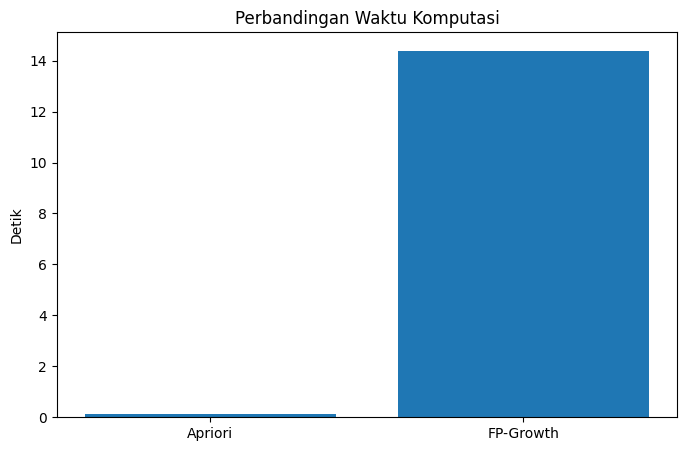

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(
    comparison['Algoritma'],
    comparison['Waktu Komputasi']
)

plt.title('Perbandingan Waktu Komputasi')
plt.ylabel('Detik')
plt.show()

## **VISUALISASI SUPPORT VS CONFIDENCE**

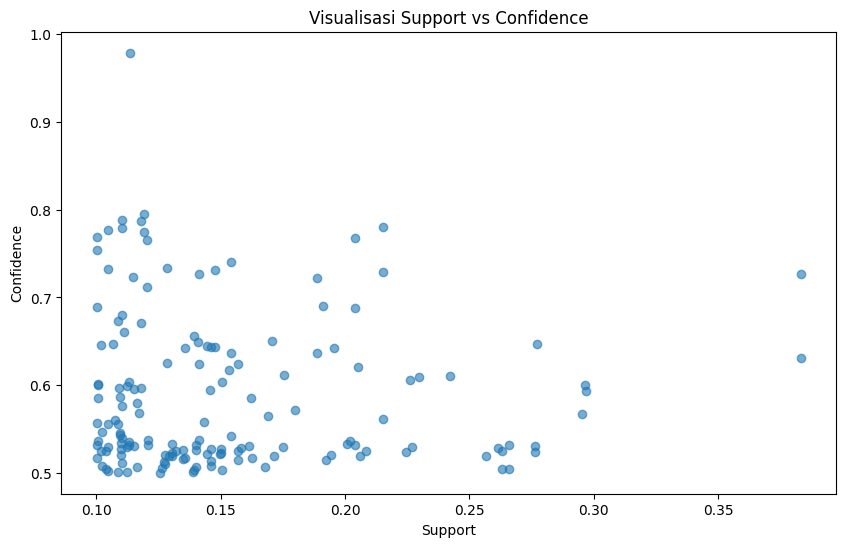

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(
    rules_fp['support'],
    rules_fp['confidence'],
    alpha=0.6
)

plt.title('Visualisasi Support vs Confidence')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()

## **TABEL ASSOCIATION RULE**

In [ ]:
best_rules = rules_fp.sort_values(
    by=['lift', 'confidence'],
    ascending=False
)

rules_table = best_rules.copy()
rules_table['antecedents'] = rules_table['antecedents'].apply(
    lambda x: ', '.join(list(x))
)

rules_table['consequents'] = rules_table['consequents'].apply(
    lambda x: ', '.join(list(x))
)

rules_table = rules_table[[
    'antecedents', 'consequents', 'support', 'confidence', 'lift'
]]

rules_table = rules_table.round(3)
rules_table.columns = ['Jika (Antecedent)', 'Maka (Consequent)', 'Support', 'Confidence', 'Lift']

print("TOP 10 ASSOCIATION RULES")
display(rules_table.head(10))

TOP 10 ASSOCIATION RULES


,Jika (Antecedent),Maka (Consequent),Support,Confidence,Lift
156,study_low,productivity_low,0.115,0.724,2.613
155,productivity_high,study_high,0.114,0.978,1.856
10,"productivity_medium, attendance_low, phone_high",study_high,0.110,0.779,1.479
61,"productivity_medium, sleep_low",study_high,0.119,0.774,1.468
31,"exercise_high, productivity_medium, phone_high",study_high,0.105,0.732,1.389
103,"productivity_medium, phone_high",study_high,0.215,0.729,1.384
56,"productivity_medium, stress_high",study_high,0.120,0.712,1.351
65,productivity_low,phone_high,0.191,0.690,1.325
62,"sleep_low, study_high",productivity_medium,0.119,0.795,1.310
23,"exercise_high, productivity_medium, attendance...",study_high,0.100,0.689,1.307


### **VISUALISASI ASSOCIATION RULE**

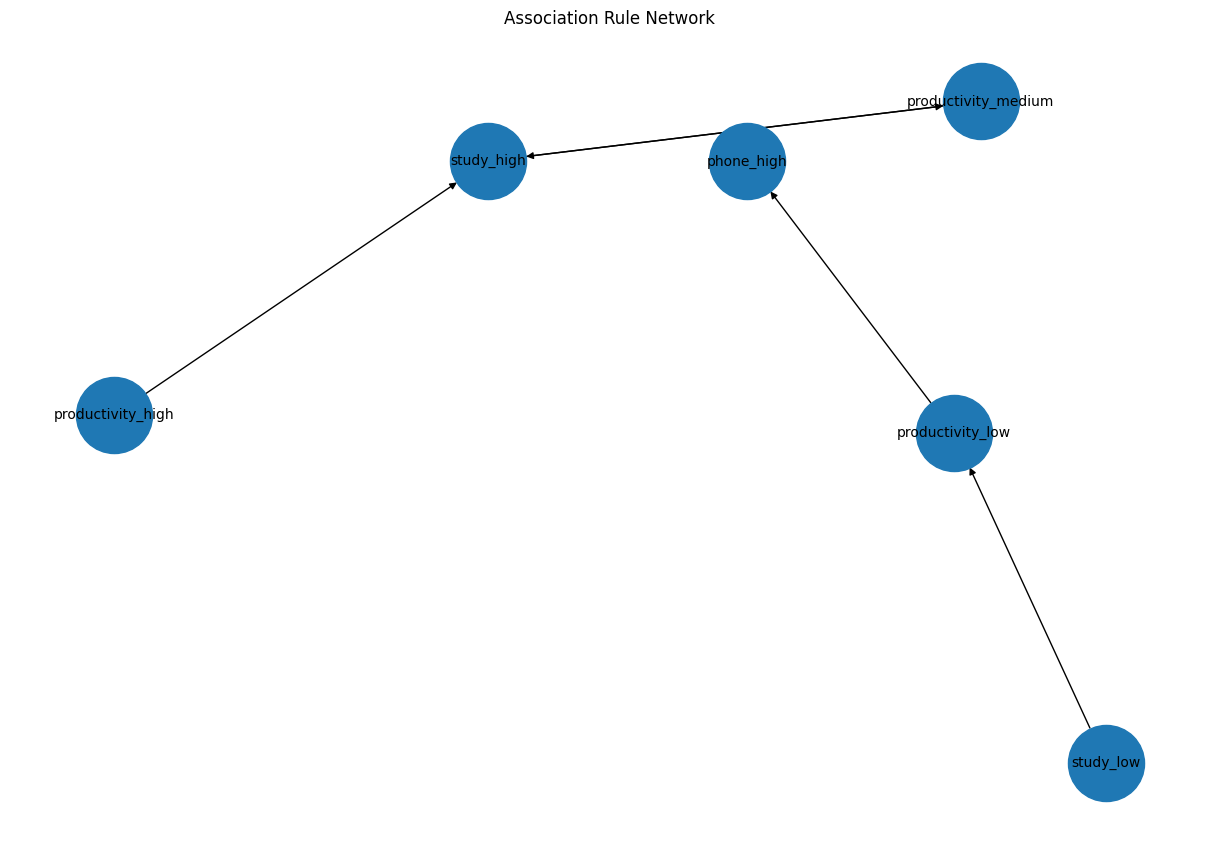

In [ ]:
top_rules = rules_fp.head(10)
G = nx.DiGraph()

for _, row in top_rules.iterrows():
    antecedent = list(row['antecedents'])[0]
    consequent = list(row['consequents'])[0]
    G.add_edge(antecedent, consequent)

plt.figure(figsize=(12,8))
pos = nx.spring_layout(G)

nx.draw(
    G, pos, with_labels=True, node_size=3000, font_size=10)

plt.title("Association Rule Network")
plt.show()

## **TOP RULE**

In [ ]:
top_rule = best_rules.iloc[0]

print("RULE TERBAIK:")

print("Jika mahasiswa memiliki pola:")
print(top_rule['antecedents'])

print("Maka cenderung memiliki:")
print(top_rule['consequents'])

print("Support :", round(top_rule['support'],3))
print("Confidence :", round(top_rule['confidence'],3))
print("Lift :", round(top_rule['lift'],3))

RULE TERBAIK:
Jika mahasiswa memiliki pola:
frozenset({'study_low'})
Maka cenderung memiliki:
frozenset({'productivity_low'})
Support : 0.115
Confidence : 0.724
Lift : 2.613


In [ ]:
df = pd.read_csv('student_productivity_distraction_dataset_20000.csv')
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [ ]:
df['age']

,age
0,23
1,20
2,29
3,27
4,24
...,...
19995,26
19996,22
19997,25
19998,22


In [ ]:
df [['age' , 'gender']].head(10)

,age,gender
0,23,Female
1,20,Male
2,29,Female
3,27,Female
4,24,Male
5,29,Other
6,21,Female
7,23,Female
8,26,Male
9,19,Female
